### Fuzzy SVM. 
Użyj go do rozwiązania wybranego problemu klasyfikacji. Porównaj wyniki z klasycznym SVM.

**importy**

In [37]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

**Fuzzy SVM - własna interpretacja**

In [38]:
class FuzzySVM:
    def __init__(self, kernel="rbf"):
        self._model = SVC(kernel=kernel)

    def _compute_memberships(self, X, y):
        
        memberships = np.zeros(len(X))
        classes = np.unique(y)

        MIN_WEIGHT = 0.1  
        MAX_WEIGHT = 1.0  

        for cls in classes:
            indexes_in_class = np.where(y == cls)[0]     
            X_in_class = X[indexes_in_class]                  
            center_of_class = X_in_class.mean(axis=0)     

            dist = np.linalg.norm(X_in_class - center_of_class, axis=1)

            if dist.max() == 0:
                norm_dist = np.zeros_like(dist)
            else:
                norm_dist = dist / dist.max()

            m = MAX_WEIGHT - norm_dist * (MAX_WEIGHT - MIN_WEIGHT)

            memberships[indexes_in_class] = m
        return memberships

    def fit(self, X, y):
        memberships = self._compute_memberships(X, y)
        self._model.fit(X, y, sample_weight=memberships)
        return self

    def predict(self, X):
        return self._model.predict(X)
    
    def score(self, X, y):
        return self._model.score(X, y)


**test**

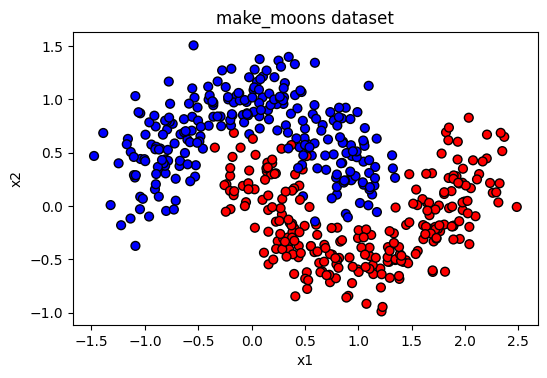


--- Using kernel: linear ---
Sklearn SVM, Accuracy: 0.90


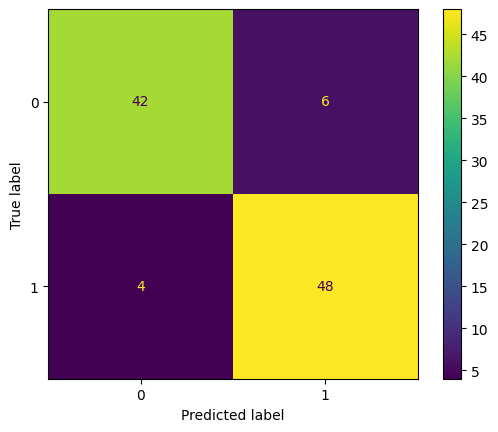

Fuzzy SVM, Accuracy: 0.89


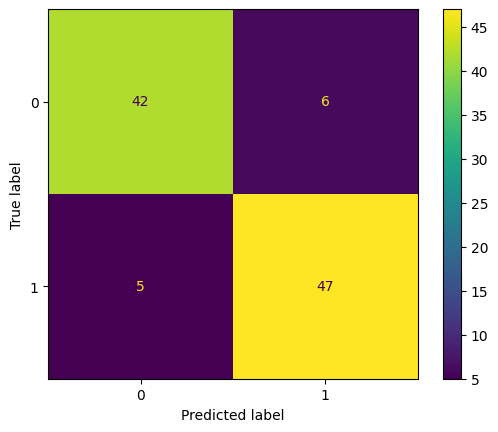


--- Using kernel: poly ---
Sklearn SVM, Accuracy: 0.92


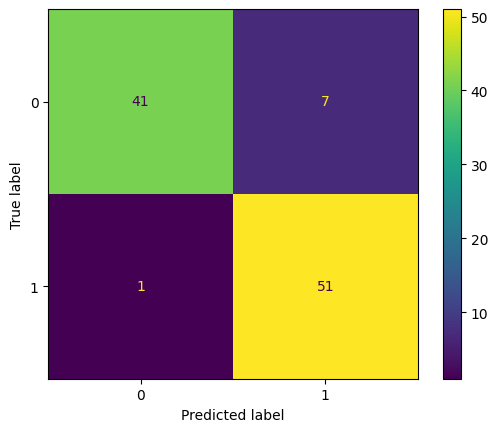

Fuzzy SVM, Accuracy: 0.92


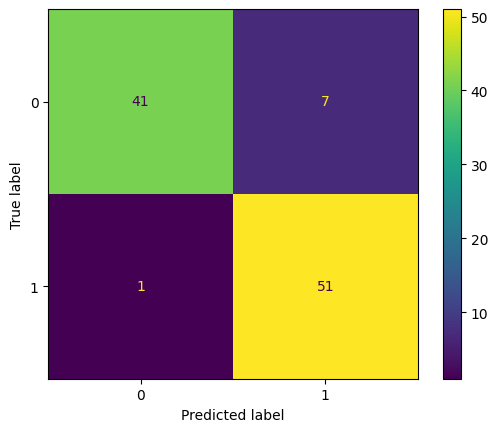


--- Using kernel: rbf ---
Sklearn SVM, Accuracy: 0.97


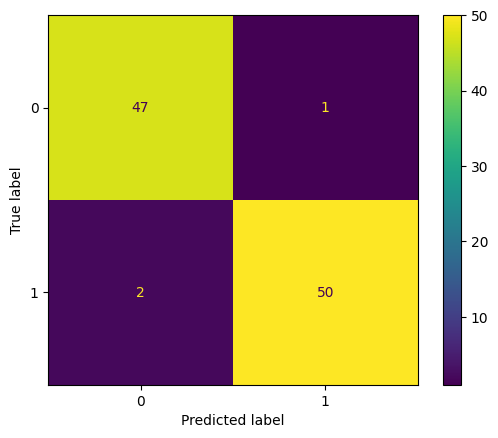

Fuzzy SVM, Accuracy: 0.98


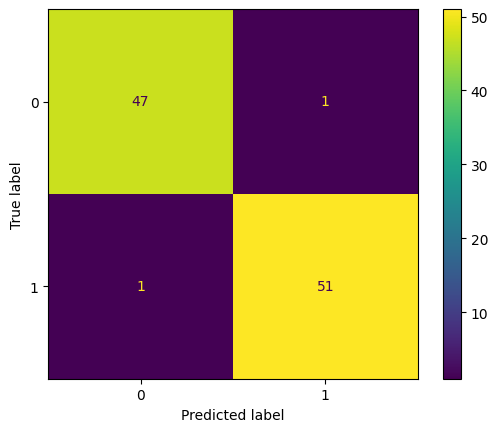


--- Using kernel: sigmoid ---
Sklearn SVM, Accuracy: 0.64


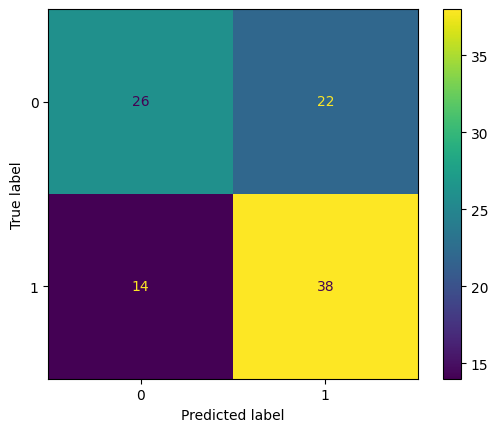

Fuzzy SVM, Accuracy: 0.69


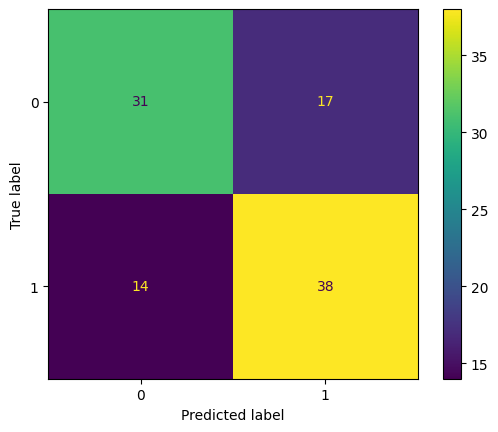

In [39]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', s=40)
plt.title('make_moons dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.gca().set_aspect('equal', 'box')
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

for KERNEL in kernels:
    print(f'\n--- Using kernel: {KERNEL} ---')

    ready_svm = SVC(kernel=KERNEL)
    ready_svm.fit(X_train, y_train)
    print(f'Sklearn SVM, Accuracy: {ready_svm.score(X_test, y_test):.2f}')
    ConfusionMatrixDisplay.from_predictions(y_test, ready_svm.predict(X_test))
    plt.show()

    fuzzy_svm = FuzzySVM(kernel=KERNEL)
    fuzzy_svm.fit(X_train, y_train)
    print(f'Fuzzy SVM, Accuracy: {fuzzy_svm.score(X_test, y_test):.2f}')
    ConfusionMatrixDisplay.from_predictions(y_test, fuzzy_svm.predict(X_test))
    plt.show()